In [103]:
"""
EDA Graphs hydrological

1. Number of flooding events over time
2. Mean daily rainfall map
3. Mean daily runoff map
4. Yearly flooded area 
5. Monthly flooded area
6. Lagged relationship between Lake Victoria water level and South Sudan flood extent

"""

from pathlib import Path
import os 
import sys
import xarray as xr
import numpy as np

notebook_dir = Path(os.getcwd())

for parent in [notebook_dir] + list(notebook_dir.parents):
    if (parent / ".git").exists():
        REPO_ROOT = parent
        break
else:
    REPO_ROOT = notebook_dir

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)

export_folder = Path("./EDA/hydrological")
export_folder.mkdir(parents=True, exist_ok=True)

print(f"Project root found at: {REPO_ROOT}")
print(f"Current working directory: {os.getcwd()}")

Project root found at: c:\Users\artur\OneDrive\Dokumenty\TUe docs\Y3Q1\Capstone DBL code\JBG060_ZHL_2026_group_12
Current working directory: c:\Users\artur\OneDrive\Dokumenty\TUe docs\Y3Q1\Capstone DBL code\JBG060_ZHL_2026_group_12


In [104]:
import numpy as np

from processing_data.loading import load_flood_masks
from processing_data.loading_impact_data import load_worldpop_area

bbox = {
    "lat_min": 8.5,
    "lat_max": 10.0,
    "lon_min": 29.5,
    "lon_max": 32.5,
}

flood_events = load_flood_masks(np.array([2024]), bbox=bbox)
population_by_year = load_worldpop_area(bbox)

print(flood_events.head())
print(population_by_year[2024])

        date       lat        lon    tile  flood_type
0 2024-01-01  8.501041  30.288542  h21v08           0
1 2024-01-01  8.501041  31.030209  h21v08           1
2 2024-01-01  8.501041  31.032291  h21v08           1
3 2024-01-01  8.501041  31.034374  h21v08           1
4 2024-01-01  8.501041  31.036459  h21v08           1
1271175.25


In [105]:
flood_events_by_day = flood_events.groupby('date')['lat'].count()
print(flood_events_by_day.head())

date
2024-01-01    46218
2024-01-02    43225
2024-01-03    40577
2024-01-04    41612
2024-01-05    42610
Name: lat, dtype: int64


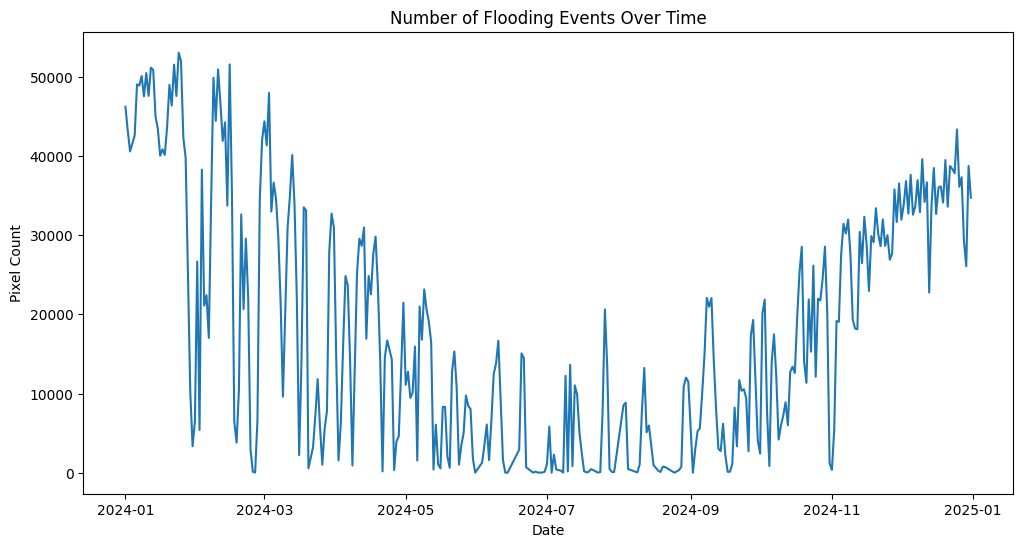

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(flood_events_by_day.index, flood_events_by_day.values)
plt.title('Number of Flooding Events Over Time')
plt.xlabel('Date')
plt.ylabel('Pixel Count')

plt.savefig("./EDA/hydrological/flooding_events_over_time.png", dpi=300, bbox_inches="tight")
plt.show()


In [107]:
# Load the data for second figure. Map with mean daily rainfall in South Sudan for years 2000-2025.

from processing_data.loading import load_rainfall_runoff
from processing_data.loading_impact_data import load_admin_boundaries

years = np.arange(2000, 2026)
rainfall_runoff_data = load_rainfall_runoff(years)
admin1, admin2 = load_admin_boundaries()

Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2000-01-01 to 2025-12-31
<xarray.Dataset> Size: 628MB
Dimensions:     (valid_time: 9497, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 76kB 2000-01-01 ... 2025-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 314MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 314MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history

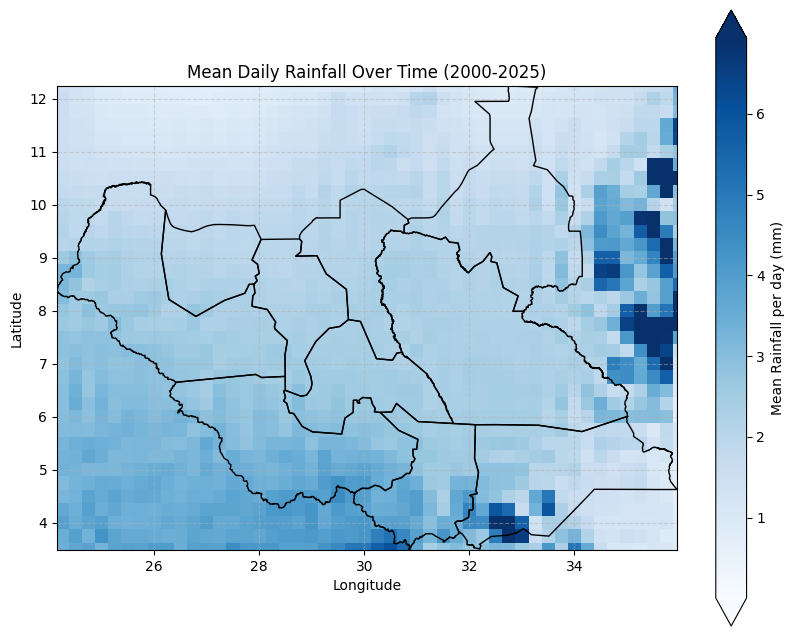

In [108]:
import matplotlib.pyplot as plt

tp = rainfall_runoff_data["tp"]

mean_rainfall = tp.mean(dim='valid_time').compute()
mean_rainfall = mean_rainfall * 1000

fig, ax = plt.subplots(figsize=(10, 8))

mean_rainfall.plot(ax=ax,cmap='Blues', robust=True, cbar_kwargs={'label': 'Mean Rainfall per day (mm)'})

admin1.boundary.plot(ax=ax, color='black', linewidth=1)


minx, miny, maxx, maxy = admin1.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title('Mean Daily Rainfall Over Time (2000-2025)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.5)

plt.savefig("./EDA/hydrological/mean_daily_rainfall.png", dpi=300, bbox_inches="tight")
plt.show()


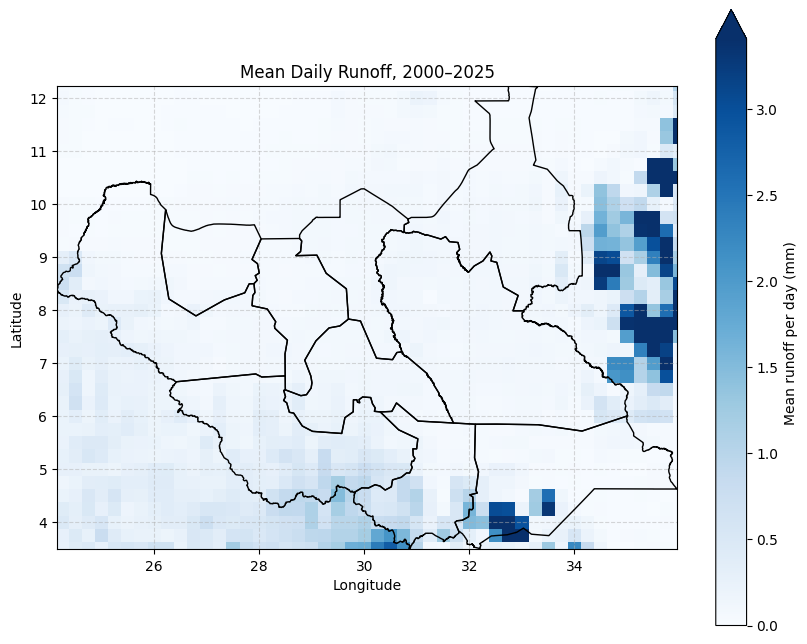

In [109]:
# Mean runoff over the valid_time dimension
ro = rainfall_runoff_data["ro"]
mean_runoff = ro.mean(dim='valid_time').compute()

# Convert from m/day to mm/day
mean_runoff = mean_runoff * 1000

fig, ax = plt.subplots(figsize=(10, 8))

mean_runoff.plot(ax=ax, cmap='Blues', robust=True, cbar_kwargs={'label': 'Mean runoff per day (mm)'})


admin1.boundary.plot(ax=ax, color='black', linewidth=1)

minx, miny, maxx, maxy = admin1.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title('Mean Daily Runoff, 2000–2025')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.5)

plt.savefig("./EDA/hydrological/mean_daily_runoff.png", dpi=300, bbox_inches="tight")
plt.show()


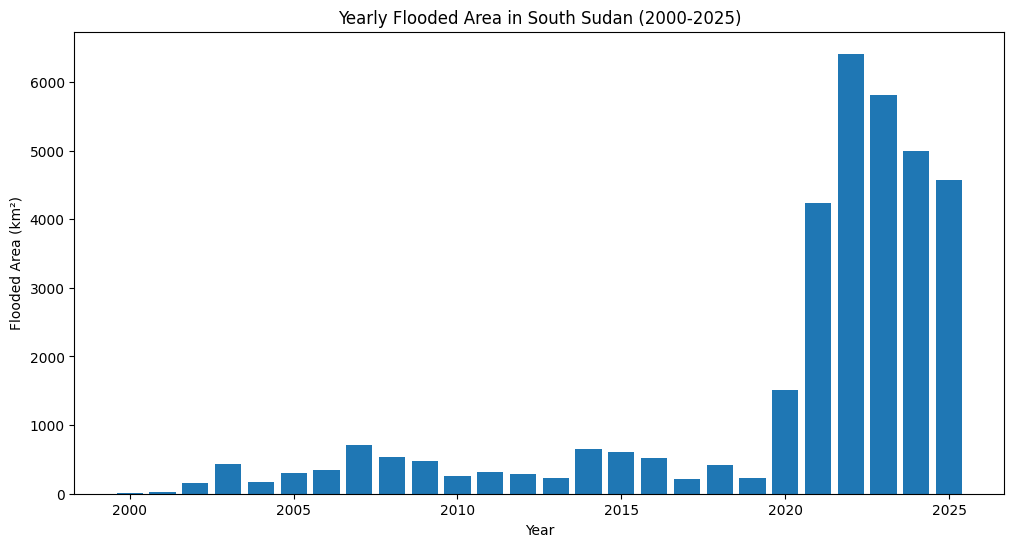

In [110]:
flood_masks = load_flood_masks(np.arange(2000, 2026), bbox=bbox)


flood_masks["year"] = flood_masks["date"].dt.year

# Count unique flooded pixels for each year
yearly_flood_extent = (
    flood_masks
    .groupby("year")
    .apply(lambda x: x[["lat", "lon"]].drop_duplicates().shape[0])
    .reset_index(name="flooded_pixels")
)

pixel_area_km2 = 0.232 * 0.232

yearly_flood_extent["flooded_area_km2"] = (yearly_flood_extent["flooded_pixels"] * pixel_area_km2)

plt.figure(figsize=(12, 6))
plt.bar(yearly_flood_extent["year"], yearly_flood_extent["flooded_area_km2"])

plt.xlabel('Year')
plt.ylabel('Flooded Area (km²)')
plt.title('Yearly Flooded Area in South Sudan (2000-2025)')

plt.savefig("./EDA/hydrological/yearly_flooded_area.png", dpi=300, bbox_inches="tight")
plt.show()


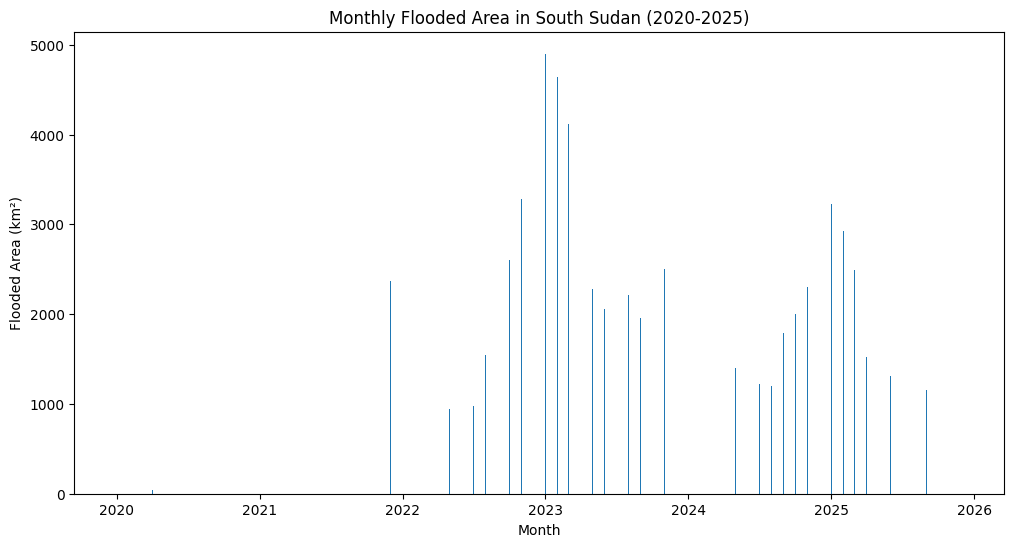

In [111]:
import pandas as pd

flood_masks_specific = load_flood_masks(np.arange(2020, 2026), bbox=bbox)
flood_masks_specific["year"] = flood_masks_specific["date"].dt.year
flood_masks_specific["month"] = flood_masks_specific["date"].dt.month


# Count unique flooded pixels for each month
monthly_flood_extent = (
    flood_masks_specific
    .groupby(["year", "month"])
    .apply(lambda x: x[["lat", "lon"]].drop_duplicates().shape[0])
    .reset_index(name="flooded_pixels")
)

pixel_area_km2 = 0.232 * 0.232

monthly_flood_extent["flooded_area_km2"] = (monthly_flood_extent["flooded_pixels"] * pixel_area_km2)

monthly_flood_extent["year_month"] = pd.to_datetime(monthly_flood_extent[["year", "month"]].assign(day=1))

plt.figure(figsize=(12, 6))
plt.bar(monthly_flood_extent["year_month"], monthly_flood_extent["flooded_area_km2"])

plt.xlabel('Month')
plt.ylabel('Flooded Area (km²)')
plt.title('Monthly Flooded Area in South Sudan (2020-2025)')

plt.savefig("./EDA/hydrological/monthly_flooded_area.png", dpi=300, bbox_inches="tight")
plt.show()


In [112]:
from processing_data.loading import load_lake_stations

flood_extent_daily = flood_masks_specific.groupby('date').apply(lambda x: x[['lat', 'lon']].drop_duplicates().shape[0]).reset_index(name='flooded_pixels')


flood_extent_daily["flooded_area_km2"] = (
    flood_extent_daily["flooded_pixels"] * pixel_area_km2
)

lake_data = load_lake_stations()
victoria = lake_data['victoria'].copy()
victoria = victoria.loc['2020':'2025']
victoria = victoria[["height_wrt_ref"]].dropna()

victoria.head()


Loading lake data for:  victoria
           mission  cycle  hour  minute  height_wrt_ref  height_err  \
date                                                                  
1992-10-07   TOPEX      2    17      34            0.46       0.042   
1992-10-17   TOPEX      3    15      33            0.47       0.042   
1992-10-27   TOPEX      4    13      31            0.51       0.042   
1992-11-06   TOPEX      5    11      30            0.51       0.042   
1992-11-16   TOPEX      6     9      28            0.49       0.042   

            backscatter_ku wet_tropo_corr iono_corr dry_tropo_corr  mode1  \
date                                                                        
1992-10-07           13.86            TMR       DOR            ERA      4   
1992-10-17           16.27            TMR       DOR            ERA      4   
1992-10-27           12.97            TMR       DOR            ERA      4   
1992-11-06           14.12            TMR       DOR            ERA      4   
1992-11

,height_wrt_ref
date,


In [113]:
import pandas as pd

# Load the Victoria lake water level data manually 

fname = "./raw_data/Water levels lakes/water_level_victoria.txt"

col_names = [
    "mission", "cycle", "date", "hour", "minute",
    "height_wrt_ref", "height_err", "backscatter_ku",
    "wet_tropo_corr", "iono_corr", "dry_tropo_corr",
    "mode1", "mode2", "ice_flag", "height_egm2008",
    "data_source_flag"
]

# Read the file and keep lines that contain 16 columns
data_lines = []

with open(fname, "r", encoding="latin-1") as f:
    for line in f:
        parts = line.strip().split()

        if len(parts) == 16:
            data_lines.append(parts)

victoria = pd.DataFrame(data_lines, columns=col_names)

# Convert the important columns
victoria["date"] = pd.to_datetime(victoria["date"], format="%Y%m%d", errors="coerce")

victoria["height_wrt_ref"] = pd.to_numeric(victoria["height_wrt_ref"], errors="coerce")

# Remove rows where the values we need are missing
victoria = victoria.dropna(subset=["date", "height_wrt_ref"])

# Sort chronologically
victoria = victoria.sort_values("date").set_index("date")

print("First date:", victoria.index.min())
print("Last date:", victoria.index.max())
print("Number of observations:", len(victoria))

print("\nMissions:")
print(victoria["mission"].value_counts())

print("\nLast observations:")
print(victoria[["mission", "height_wrt_ref"]].tail())

First date: 1992-09-27 00:00:00
Last date: 2026-05-18 00:00:00
Number of observations: 1331

Missions:
mission
TOPEX    332
JASN2    302
JASN1    253
JASN3    222
SEN6A    195
POSDN     27
Name: count, dtype: int64

Last observations:
           mission  height_wrt_ref
date                              
2026-04-08   SEN6A            1.84
2026-04-18   SEN6A            1.86
2026-04-28   SEN6A            1.89
2026-05-08   SEN6A            1.91
2026-05-18   SEN6A            1.95


In [114]:
# Prepare flood and lake victoria data for plotting.

flood_extent_daily = flood_masks_specific.groupby('date').apply(lambda x: x[['lat', 'lon']].drop_duplicates().shape[0]).reset_index(name='flooded_pixels')

pixel_area_km2 = 0.232 * 0.232

flood_extent_daily["flooded_area_km2"] = (flood_extent_daily["flooded_pixels"] * pixel_area_km2)

victoria_specific = victoria.loc["2020":"2025", ["height_wrt_ref"]].copy()

victoria_specific = victoria_specific.sort_index()

print(victoria_specific.head())
print(victoria_specific.tail())


            height_wrt_ref
date                      
2020-01-09            1.39
2020-01-19            1.46
2020-01-29            1.48
2020-02-18            1.63
2020-02-28            1.68
            height_wrt_ref
date                      
2025-11-20            1.64
2025-11-30            1.57
2025-12-10            1.53
2025-12-20            1.54
2025-12-30            1.62


In [115]:
from scipy.stats import pearsonr, spearmanr

lag_results_long = []

for lag in range(0, 401, 10):

    # Shift Victoria observations forward by the tested lag
    victoria_lagged = victoria_specific.reset_index()

    victoria_lagged["target_date"] = (victoria_lagged["date"] + pd.Timedelta(days=lag))

    # Match to the nearest flood observation
    merged = pd.merge_asof(
        victoria_lagged.sort_values("target_date"),
        flood_extent_daily[["date", "flooded_area_km2"]].sort_values("date"),
        left_on="target_date",
        right_on="date",
        direction="nearest",
        tolerance=pd.Timedelta(days=2)
    )

    merged = merged.dropna(subset=["height_wrt_ref", "flooded_area_km2"])

    if len(merged) >= 3:

        pearson_r, pearson_p = pearsonr(merged["height_wrt_ref"], merged["flooded_area_km2"])
        spearman_r, spearman_p = spearmanr(merged["height_wrt_ref"], merged["flooded_area_km2"])

    else:
        pearson_r = pearson_p = np.nan
        spearman_r = spearman_p = np.nan

    lag_results_long.append({
        "lag_days": lag,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "n": len(merged)
    })

lag_results_long = pd.DataFrame(lag_results_long)

print(lag_results_long.to_string(index=False))

 lag_days  pearson_r    pearson_p  spearman_r   spearman_p   n
        0  -0.050778 4.250213e-01   -0.358160 5.978341e-09 249
       10  -0.055101 3.885505e-01   -0.394194 1.310863e-10 247
       20  -0.055396 3.860192e-01   -0.454248 5.600502e-14 247
       30  -0.054822 3.919336e-01   -0.456503 4.570181e-14 246
       40  -0.054578 3.950231e-01   -0.480058 1.581441e-15 245
       50  -0.055999 3.837960e-01   -0.503753 4.169795e-17 244
       60  -0.057375 3.741913e-01   -0.516840 6.265266e-18 242
       70  -0.572083 1.952173e-22   -0.551221 1.232562e-20 242
       80  -0.056282 3.833759e-01   -0.524032 1.803096e-18 242
       90  -0.572843 1.669225e-22   -0.517022 6.072567e-18 242
      100  -0.058480 3.670533e-01   -0.500173 1.346428e-16 240
      110  -0.055435 3.935673e-01   -0.479322 3.921477e-15 239
      120  -0.055463 3.943257e-01   -0.465748 3.232864e-14 238
      130  -0.049388 4.482304e-01   -0.413440 3.046302e-11 238
      140  -0.056287 3.883399e-01   -0.386605 7.207028e

In [116]:
best_pearson_long = lag_results_long.loc[lag_results_long["pearson_r"].abs().idxmax()]
best_spearman_long = lag_results_long.loc[lag_results_long["spearman_r"].abs().idxmax()]

print("Best Pearson:")
print(best_pearson_long)

print("\nBest Spearman:")
print(best_spearman_long)

Best Pearson:
lag_days      9.000000e+01
pearson_r    -5.728428e-01
pearson_p     1.669225e-22
spearman_r   -5.170223e-01
spearman_p    6.072567e-18
n             2.420000e+02
Name: 9, dtype: float64

Best Spearman:
lag_days      7.000000e+01
pearson_r    -5.720829e-01
pearson_p     1.952173e-22
spearman_r   -5.512207e-01
spearman_p    1.232562e-20
n             2.420000e+02
Name: 7, dtype: float64


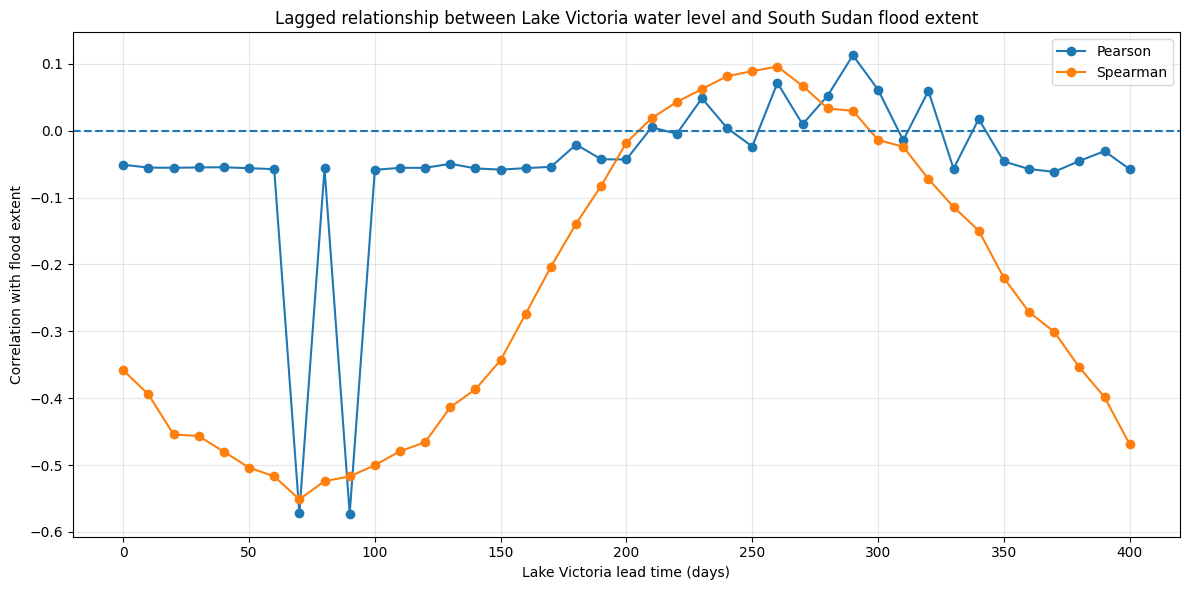

In [117]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(lag_results_long["lag_days"], lag_results_long["pearson_r"], marker="o", label="Pearson")
plt.plot(lag_results_long["lag_days"], lag_results_long["spearman_r"], marker="o", label="Spearman")

plt.axhline(0, linestyle="--")
plt.xlabel("Lake Victoria lead time (days)")
plt.ylabel("Correlation with flood extent")
plt.title("Lagged relationship between Lake Victoria water level and South Sudan flood extent")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("./EDA/hydrological/lagged_relationship_victoria_flood_extent.png", dpi=300, bbox_inches="tight")
plt.show()

In [118]:
from pathlib import Path

#Export the figures 
export_folder = Path("./EDA/hydrological")
export_folder.mkdir(parents=True, exist_ok=True)

figure_names = ['flooding_events_over_time', 'mean_daily_rainfall', 'mean_daily_runoff', 'yearly_flooded_area', 'monthly_flooded_area', 'lagged_relationship_victoria_flood_extent']

figures = plt.get_fignums()

for i in range(min(len(figures), len(figure_names))):
    fig_num = figures[i]
    name = figure_names[i]
    
    fig = plt.figure(fig_num)
    fig.savefig(export_folder / f"{name}.png", dpi=300, bbox_inches="tight")


print(f'Figures saved in {export_folder.resolve()}')

Figures saved in C:\Users\artur\OneDrive\Dokumenty\TUe docs\Y3Q1\Capstone DBL code\JBG060_ZHL_2026_group_12\EDA\hydrological


In [119]:
print(plt.get_fignums())

[]
